# Humoto → SMPL-X / InterAct — visual inspection

All processing logic lives in `process/process_humoto.py`. This notebook only **loads** that module and **visualizes** results. Edit the `.py`; cells here pick up changes via `autoreload`.

Run order: imports → load models → process one sequence → overlay check → mesh+object render → video.

In [25]:
%load_ext autoreload
%autoreload 2

import os, numpy as np, torch, trimesh
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from scipy.spatial.transform import Rotation as Rot

from process.process_humoto import (
    process_humoto_sequence, load_models, load_targets,
    BODY_CORR, PARENTS, BODY_NAMES, Z_TO_Y_MAT,
    HUMOTO_UPBONE, HUMOTO_RAW, OUTPUT_ROOT,
)
print('imports OK')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
imports OK


In [26]:
# Build SMPL-X + Mixamo models once (reused by every cell below)
m, mx_model = load_models('./models')
print('models loaded')

models loaded


In [ ]:
# Choose the sequence to inspect
SEQ_NAME    = 'baking_with_spatula_mixing_bowl_and_scooping_to_tray-244'
PRIMARY_OBJ = 'spatula'
PKL_PATH    = os.path.join(HUMOTO_UPBONE, SEQ_NAME, f'{SEQ_NAME}.pkl')
GLB_PATH    = os.path.join(HUMOTO_RAW,    SEQ_NAME, f'{SEQ_NAME}.glb')

result = process_humoto_sequence(
    pkl_path=PKL_PATH, glb_path=GLB_PATH,
    seq_name=SEQ_NAME, primary_object=PRIMARY_OBJ,
    smplx_model=m, mx_model=mx_model, output_root=f'{OUTPUT_ROOT}', seed=0,
)
result

[1/4] baking_with_spatula_mixing_bowl_and_scooping_to_tray-244: T=293, objects=['mixing_bowl', 'spatula', 'table', 'tray']

=== Fitting sequence (T=293) ===


per-frame pose fit: 100%|██████████| 292/292 [04:30<00:00,  1.08it/s]

[2/4] fit: mean=2.98cm  max=3.09cm  ||beta||=0.86
[3/4] wrote human.npz + object.npz → ./data/humoto_temp/sequences_canonical/baking_with_spatula_mixing_bowl_and_scooping_to_tray-244
[4/4] wrote spatula mesh + sample_points → ./data/humoto_temp/objects/spatula


{'seq_dir': './data/humoto_temp/sequences_canonical/baking_with_spatula_mixing_bowl_and_scooping_to_tray-244',
 'obj_dir': './data/humoto_temp/objects/spatula',
 'betas': array([-0.8273615 ,  0.13182306, -0.13495483,  0.08120145,  0.03543864,
         0.07834297, -0.01715355, -0.00280334, -0.07384025, -0.00802231,
         0.04073953, -0.04474779, -0.0382368 ,  0.01456073,  0.00657634,
         0.0072595 ], dtype=float32),
 'mean_err_cm': 2.976578287780285,
 'max_err_cm': 3.0872892588377,
 'T': 293}

In [28]:
# Load what we just wrote, so the plots below reflect the on-disk files
seq_dir = result['seq_dir']
obj_dir = result['obj_dir']
human   = np.load(os.path.join(seq_dir, 'human.npz'), allow_pickle=True)
objnpz  = np.load(os.path.join(seq_dir, 'object.npz'), allow_pickle=True)

poses = human['poses']                 # (T, 156)
betas = human['betas']                 # (16,)
trans = human['trans']                 # (T, 3)
T     = poses.shape[0]
betas_fit = torch.from_numpy(betas)[None].float()
fitted_go = poses[:, :3].astype(np.float32)
fitted_bp = poses[:, 3:66].astype(np.float32)
fitted_tr = trans.astype(np.float32)

obj_angles = objnpz['angles']          # (T, 3)
obj_trans  = objnpz['trans']           # (T, 3)
spatula_obj = trimesh.load(os.path.join(obj_dir, f'{PRIMARY_OBJ}.obj'))

# Mixamo joint targets (the fit's ground truth), so we can overlay target vs fitted
all_targets, _ = load_targets(PKL_PATH, mx_model)   # (T, 22, 3) y-up
print(f'T={T}, betas norm={np.linalg.norm(betas):.2f}, mean_err={result["mean_err_cm"]:.2f}cm, '
      f'all_targets={all_targets.shape}')

T=293, betas norm=0.86, mean_err=2.98cm, all_targets=(293, 22, 3)


## 1. Marker silhouette (frame 0)
Run SMPL-X forward, confirm the body looks human and stands at a sensible height.

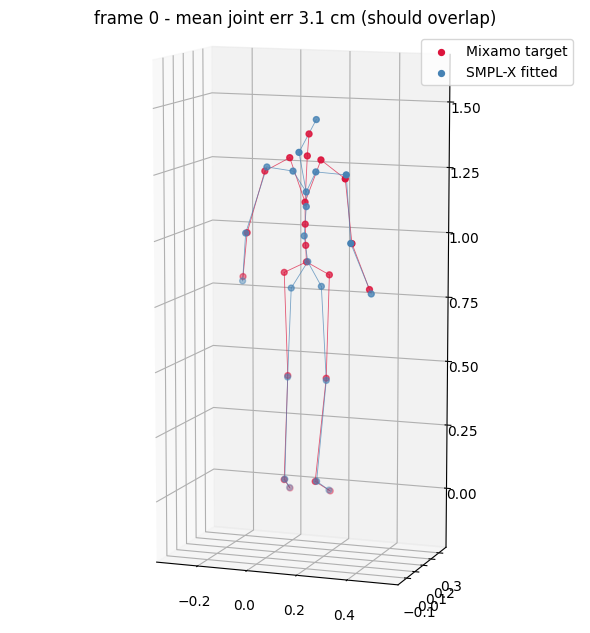

In [33]:
def render_overlay(t):
    """Overlay Mixamo target (crimson) vs fitted SMPL-X joints (blue) for frame t."""
    with torch.no_grad():
        pred = m(global_orient=torch.from_numpy(fitted_go[t:t+1]),
                 body_pose    =torch.from_numpy(fitted_bp[t:t+1]),
                 transl       =torch.from_numpy(fitted_tr[t:t+1]),
                 betas        =betas_fit).joints[0, :22].numpy()
    target = all_targets[t]
    err = np.linalg.norm(pred - target, axis=1).mean() * 100   # this frame's mean err (cm)
    both = np.vstack([target, pred]); lo, hi = both.min(0) - 0.2, both.max(0) + 0.2

    fig = plt.figure(figsize=(6, 7))
    ax = fig.add_subplot(111, projection='3d')
    for J, lbl, c in [(target, 'Mixamo target', 'crimson'),
                      (pred,   'SMPL-X fitted', 'steelblue')]:
        for k, p in enumerate(PARENTS):
            if p >= 0:
                ax.plot([J[p,0],J[k,0]],[J[p,2],J[k,2]],[J[p,1],J[k,1]],
                        '-', color=c, lw=0.6, alpha=0.7)
        ax.scatter(J[:,0], J[:,2], J[:,1], c=c, s=18, label=lbl)
    ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[2], hi[2]); ax.set_zlim(lo[1], hi[1])
    ax.set_box_aspect((hi-lo)[[0, 2, 1]]); ax.view_init(elev=10, azim=-70)
    ax.legend(); ax.set_title(f'frame {t} - mean joint err {err:.1f} cm (should overlap)')
    plt.tight_layout(); plt.show()

render_overlay(0)

## 2. SMPL-X mesh + object, multi-angle (frame 80)
Compare against the humoto thumbnail PNG. azim=200 ≈ facing the camera.

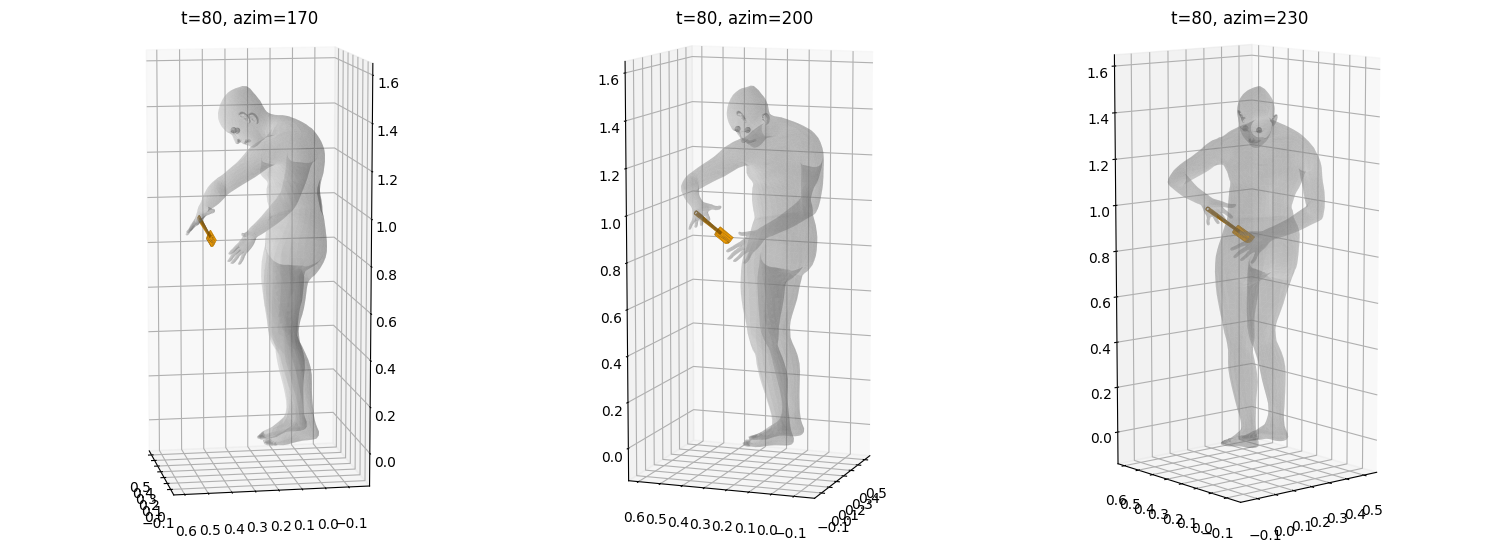

In [30]:
def render_frame(t, azims=(170, 200, 230)):
    with torch.no_grad():
        out = m(global_orient=torch.from_numpy(fitted_go[t:t+1]),
                body_pose    =torch.from_numpy(fitted_bp[t:t+1]),
                transl       =torch.from_numpy(fitted_tr[t:t+1]),
                betas        =betas_fit)
    Vb, Fb = out.vertices[0].numpy(), m.faces
    R_t = Rot.from_rotvec(obj_angles[t]).as_matrix()
    Vo = spatula_obj.vertices @ R_t.T + obj_trans[t]
    Fo = spatula_obj.faces
    pts = np.vstack([Vb, Vo]); lo, hi = pts.min(0) - 0.1, pts.max(0) + 0.1

    fig = plt.figure(figsize=(5 * len(azims), 6))
    for i, az in enumerate(azims):
        ax = fig.add_subplot(1, len(azims), i + 1, projection='3d')
        ax.plot_trisurf(Vb[:,0], Vb[:,2], Vb[:,1], triangles=Fb,
                        color='lightgray', alpha=0.3, linewidth=0)
        ax.plot_trisurf(Vo[:,0], Vo[:,2], Vo[:,1], triangles=Fo,
                        color='orange', alpha=0.95, linewidth=0)
        ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[2], hi[2]); ax.set_zlim(lo[1], hi[1])
        ax.set_box_aspect(((hi-lo)[0], (hi-lo)[2], (hi-lo)[1]))
        ax.view_init(elev=10, azim=az); ax.set_title(f't={t}, azim={az}')
    plt.tight_layout(); plt.show()

render_frame(80)

## Render video by running `visualization/visualize.py`

Runs InterAct's official visualization **script** as a subprocess — identical to
`python visualization/visualize.py humoto` from the terminal. This reuses the exact
CLI code path (not a re-implementation), so the output matches what you'd get on the
command line.

Requires the edits already in `visualize.py`: the `HUMOTO` dispatch branch, the
commented-out SMPL-H blocks, and `sys.path.append('./text2interaction')`.

Output → `./results/HUMOTO_<seq>_<obj>.mp4` (one per sequence in `data/humoto/sequences_canonical/`).

In [34]:
import subprocess, sys, glob, os

# Same as: python visualization/visualize.py humoto
proc = subprocess.run(
    [sys.executable, 'visualization/visualize.py', 'humoto'],
    capture_output=True, text=True,
)
print('return code:', proc.returncode)
print('--- stdout (tail) ---')
print(proc.stdout[-2000:])
if proc.returncode != 0:
    print('--- stderr (tail) ---')
    print(proc.stderr[-3000:])

# List the resulting videos
for mp4 in sorted(glob.glob('./results/HUMOTO_*.mp4')):
    print('video:', mp4, f'({os.path.getsize(mp4)//1024} KB)')

KeyboardInterrupt: 

## Play Ground 
Checking if the demo run the same as the process humotot.py 

In [ ]:
import numpy as np, os, filecmp

def compare_humoto_outputs(dir_a, dir_b):
    """Compare every output file under dir_a against its counterpart in dir_b."""
    def cmp_npz(pa, pb):
        a, b = np.load(pa, allow_pickle=True), np.load(pb, allow_pickle=True)
        if set(a.files) != set(b.files): return f'KEY MISMATCH'
        parts = []
        for k in a.files:
            va, vb = a[k], b[k]
            if va.shape != vb.shape: parts.append(f'{k}:SHAPE'); continue
            if va.dtype.kind in 'fiub':
                parts.append(f'{k}:{np.abs(va.astype(float)-vb.astype(float)).max():.2e}')
            else:
                parts.append(f'{k}:{"eq" if (va==vb).all() else "DIFF"}')
        return '  '.join(parts)

    ok = True
    for root, _, files in os.walk(dir_a):
        for f in files:
            pa = os.path.join(root, f); pb = pa.replace(dir_a, dir_b, 1)
            rel = os.path.relpath(pa, dir_a)
            if not os.path.exists(pb):
                print(f'[MISSING] {rel}'); ok = False; continue
            if f.endswith('.npz'):   print(f'{rel}: {cmp_npz(pa, pb)}')
            elif f.endswith('.npy'): print(f'{rel}: maxdiff={np.abs(np.load(pa)-np.load(pb)).max():.2e}')
            elif f.endswith('.obj'): print(f'{rel}: {"identical" if filecmp.cmp(pa, pb, shallow=False) else "DIFFERENT"}')
    return ok

compare_humoto_outputs('data/humoto_temp', 'data/humoto')


Test trimesh.sample.sample_surface vs naive approach 

area-weighted (ours)      max gap=  0.9cm ( 3.3% of 26cm diag)  mean gap=0.3cm  unique pts=340
naive vertex              max gap=  3.3cm (12.8% of 26cm diag)  mean gap=0.9cm  unique pts=243


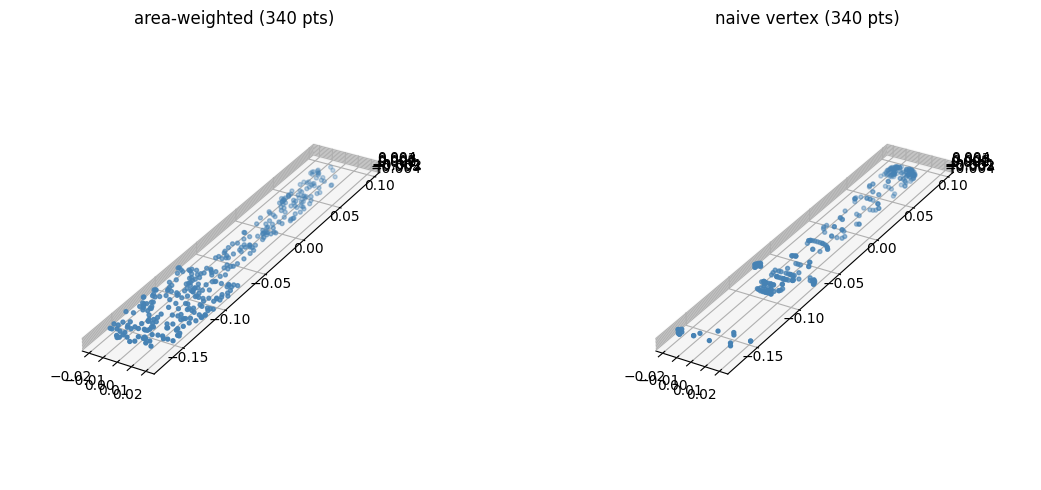

In [ ]:
import trimesh, numpy as np
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

obj_dir = "/home/natcha/Downloads/projects/InterAct/data/humoto/objects/spatula"

mesh = trimesh.load(f'{obj_dir}/spatula.obj')

# Method A: our area-weighted surface sampling
np.random.seed(0)
pts_area, _ = trimesh.sample.sample_surface(mesh, 340)

# Method B: naive random vertex subsample (what could clump)
np.random.seed(0)
vidx = np.random.choice(len(mesh.vertices), 340, replace=True)
pts_vert = mesh.vertices[vidx]

# Coverage metric: sample a DENSE reference set, measure distance from each
# reference point to the nearest of the 340. The MAX = largest uncovered gap.
ref, _ = trimesh.sample.sample_surface(mesh, 5000)
diag = np.linalg.norm(mesh.bounds[1] - mesh.bounds[0])   # object diagonal for scale

for name, pts in [('area-weighted (ours)', pts_area), ('naive vertex', pts_vert)]:
    tree = cKDTree(pts)
    gaps, _ = tree.query(ref)                 # nearest-sample distance for each ref point
    print(f"{name:24s}  max gap={gaps.max()*100:5.1f}cm "
          f"({gaps.max()/diag*100:4.1f}% of {diag*100:.0f}cm diag)  "
          f"mean gap={gaps.mean()*100:.1f}cm  unique pts={len(np.unique(pts,axis=0))}")

# Visualize both
fig = plt.figure(figsize=(12, 5))
for i, (name, pts) in enumerate([('area-weighted', pts_area), ('naive vertex', pts_vert)]):
    ax = fig.add_subplot(1, 2, i+1, projection='3d')
    ax.scatter(pts[:,0], pts[:,1], pts[:,2], s=8, c='steelblue')
    ax.set_title(f"{name} (340 pts)")
    ax.set_box_aspect((mesh.bounds[1]-mesh.bounds[0]))
plt.tight_layout(); plt.show()
